# Initialization

In [1]:
# imports
# Statistics
import seaborn as sns
import pandas as pd
import numpy as np

# Plotting
import matplotlib as mlp
import matplotlib.pyplot as plt, mpld3 #plotting and html plots
plt.style.use('dark_background')
#plt.style.use('default')
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from IPython.core.display import display, HTML
#display(HTML("<style>.container { width:100% !important; }</style>"))
#from ipywidgets import interact

# Regular Expression searching
import re

# Suite2p for TIFF file analysis
import suite2p
from suite2p.run_s2p import run_s2p, default_ops
from suite2p.registration import register


# Used for Popups
import tkinter as tk

import nest_asyncio

# for progress bar support
from tqdm import tqdm

# interact with system
import os
import sys
import copy


# statistics
import scipy
import math


# Mesc file analysis
import h5py
from tifffile import tifffile, imread
import pathlib


# add root directory to be able to import packages
# todo: make all packages installable so they can be called/imported by environment
#module_path = os.path.abspath(os.path.join('../'))
#sys.path.append(module_path)

from manifolds.donlabtools.utils.calcium import calcium
from manifolds.donlabtools.utils.calcium.calcium import *
from Classes import Analyzer, Session, Animal, Vizualizer, Unit, Binary_loader, Merger, load_all, run_cabin_corr
from Helper import *

C:\Users\mauls\AppData\Local\Temp\ipykernel_4640\946593876.py:15: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


## Settings

In [2]:
# Init Directories and Notebook settings
root_dir = "\\\\toucan-all.scicore.unibas.ch\\donafl00-calcium$\\Users\\Sergej\\Steffen_Experiments"  
#root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments" 
#root_dir = "D:\\Steffen_Experiments"  
#root_dir = "F:\\Steffen_Experiments"
Animal.root_dir = root_dir
#root_dir = "D:\\Rodrigo"
#root_dir = "D:\\Other_Rodrigo_Data"
year_list = ["2021", "2022"]
print(root_dir)
wanted_animal_ids = ["DON-009192", "DON-010473"]#["DON-002865", "DON-008497", "DON-008498", "DON-008499", "DON-009191", "DON-009192", "DON-010473", "DON-010477"]
#wanted_animal_ids = ["DON-002865", "DON-008497", "DON-008498", "DON-008499", "DON-009191", "DON-009192", "DON-010473", "DON-010477"]
#wanted_animal_ids = ["DON-009192", "DON-009191"]
#animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, generate=False) # Load all animals
animals = load_all(root_dir) # Load all animals
#animals = load_all(root_dir, generate=False) # Load all animals
#animals = load_all(root_dir, generate=True) # Load all animals
#animals = load_all(root_dir, generate=True, units="single")#, delete=True) # Load all animals


#animal.sessions[session_id].run_suite2p(regenerate=True, units="S1")
#animal.sessions[session_id].run_suite2p(regenerate=True, units=["S1", "S2"])
#animals["DON-009192"].sessions["20220306"].get_s2p_folder_paths(generate=True, regenerate=True, units="single")
#animals["DON-009192"].sessions["20220221"].get_s2p_folder_paths(generate=True, regenerate=True, units="single")

#anz = Analyzer()
viz = Vizualizer(animals, save_dir=root_dir)
plotting = False


%matplotlib inline
#%matplotlib tk
%autosave 180
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments
Loading animal: DON-002865
Loading session: DON-002865 20210210
Finished DON-002865: 20210210
Loading session: DON-002865 20210211
Finished DON-002865: 20210211
Loading session: DON-002865 20210212
Finished DON-002865: 20210212
Loading session: DON-002865 20210213
Finished DON-002865: 20210213
Loading session: DON-002865 20210214
Finished DON-002865: 20210214
Loading session: DON-002865 20210215
Finished DON-002865: 20210215
Loading session: DON-002865 20210216
Finished DON-002865: 20210216
Loading session: DON-002865 20210217
Finished DON-002865: 20210217
Loading session: DON-002865 20210218
Finished DON-002865: 20210218
Loading session: DON-002865 20210219
Finished DON-002865: 20210219
Loading animal: DON-003165
Loading session: DON-003165 20210211
Finished DON-003165: 20210211
Loading session: DON-003165 20210213
Finished DON-003165: 20210213
Loading session: DON-003165 20210215
Finished DON-003165: 20

Autosaving every 180 seconds


# Current Work

## Testing Cabincorr

In [27]:
animal_ids = {"DON-009192": ["20220330", "20220325"], "DON-010473": ["20220511"]}
unit_id = "merged"
for animal_id, animal in animals.items():
    for session_id, session in animal.sessions.items():
        if session_id in animal_ids[animal_id]:
            print(f"{animal_id} {session_id} {unit_id}")
            bin_traces_zip = session.load_cabincorr_data(unit_id=unit_id)
            break
    break

DON-009192 20220325 merged


In [61]:
#search if np.nan or None is present in arrays
#--> it is not
for key, value in bin_traces_zip.items():
    print(f"{key}")
    try:
        print(value.shape[1])
        print(np.sum(np.isnan(value)))
        print(np.sum(np.array(value)==None))
    except:
        pass

F_raw
83622
0
0
F_filtered
83622
0
0
F_detrended
83622
0
0
F_processed
83622
0
0
F_onphase
83622
0
0
F_upphase
83622
0
0
stds
derivative
83622
0
0
der_min_slope
spks
spks_smooth_upphase
high_cutoff
low_cutoff
detrend_model_order
oasis_x_F
oasis_thresh_prefilter
min_thresh_std_oasis
min_thresh_std_onphase
min_thresh_std_upphase
min_width_event_onphase
min_width_event_upphase
min_width_event_oasis
min_event_amplitude
DFF
83622
0
0


In [ ]:
candidates = [rasters, rasters_DFF]

## Testing Own Pipeline

In [3]:
print("Failed session runs:")
failed_s2p_dict = {}
failed_own_dict = {}
for animal_id, animal in cell_numbers_dict.items():
    sorted_ages, iscells, notgeldrying = get_sorted_cells_notgeldyring_lists(animal)
    failed_s2p = np.array(iscells)==-1
    failed = np.array(notgeldrying)==-1
    failed_s2p_sess_list = np.array(list(animals[animal_id].sessions.keys()))[failed_s2p]
    failed_own_sess_list = np.array(list(animals[animal_id].sessions.keys()))[failed]
    failed_s2p_dict [animal_id] = {}
    failed_own_dict [animal_id] = {}
    for sess in failed_s2p_sess_list:
        failed_s2p_dict[animal_id][sess] = {}
    for sess in failed_own_sess_list:    
        failed_own_dict[animal_id][sess] = {}
    print(f"{animal_id} S2P: {failed_s2p_sess_list}")
    print(f"{animal_id} Own Pipeline: {failed_own_sess_list}")
    print("----------------------------------------")


#Fixing bugs "Done"
"""# No fluoresence Data found by Suite2p = [["DON-010473", "20220510"]] 

# 3: ValueError: cannot reshape array of size 0 into shape ()
#to_fix = [["DON-009192", "20220307"]]

# 6: ValueError: Maximum allowed size exceeded
to_fix = [["DON-009191", "20220215"]]

for animal_id, session_id in to_fix:
    session = animals[animal_id].sessions[session_id]
    print(animal_id)
    print(session_id)
    session.get_tiff_data_paths(generate=True, regenerate=False, unit_ids="all")
    session.get_s2p_folder_paths(generate=True, regenerate=False, unit_ids="single")
    session.get_cabincorr_data_paths(generate=True, regenerate=False, unit_ids="all")
    session.get_cabincorr_data_paths(generate=True, regenerate=False, unit_ids="single")
    break"""

Failed session runs:


NameError: name 'cell_numbers_dict' is not defined

### Search for fitting output/error files to look into breaking message

In [ ]:
output_path = r"C:\Users\mauls\OneDrive\Desktop\outputs"
file_names = get_files(output_path, ending="o")
for fname in file_names:
    fpath = os.path.join(output_path, fname)
    with open(fpath, "r") as f:
        text = f.read()
    for animal_id, failed_sessions in failed_s2p_dict.items():
        for session_id, outputs in failed_sessions.items():
            if animal_id in text and session_id in text:
                outputs["o"] = text
                fpath_error = fpath[:-1]+"e"
                with open(fpath_error, "r") as fe:
                    outputs["e"] = fe.read()
    for animal_id, failed_sessions in failed_own_dict.items():
        for session_id, outputs in failed_sessions.items():
            if animal_id in text and session_id in text:
                outputs["o"] = text
                fpath_error = fpath[:-1]+"e"
                with open(fpath_error, "r") as fe:
                    outputs["e"] = fe.read()

NameError: name 'failed_s2p_dict' is not defined

In [ ]:
for animal_id, failed_sessions in failed_s2p_dict.items():
#for animal_id, failed_sessions in failed_own_dict.items():
    for session_id, outputs in failed_sessions.items():
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"{animal_id}    {session_id}")
        try:
            print(outputs["e"])
        except:
            print("some error occured")

In [ ]:
for animal_id, failed_sessions in failed_own_dict.items():
    for session_id, outputs in failed_sessions.items():
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"------------------------------------------------------------------------------------------------------")
        print(f"{animal_id}    {session_id}")
        try: 
            print(outputs["e"])
        except:
            print("some error occured")

## Pipeline Comparisson Statistics, Plots

In [3]:
cell_numbers_dict = extract_cell_numbers(animals)
# Create table to show statistics for comparison of S2P vs Own Pipeline
pipeline_stats = summary_df_s2p_vs_geldrying(cell_numbers_dict)
display(pipeline_stats)

,iscells,notgeldrying,survived_cells,sess count,Failed_S2P,Failed_Own,Failed_corr,Failed_gel_corr
animal_id,,,,,,,,
DON-002865,6100,5171,0.847705,10,0.000000,0.000000,0.000000,0.000000
DON-003165,3091,2116,0.684568,10,0.000000,0.000000,0.000000,0.000000
DON-003343,6915,6058,0.876067,10,0.000000,0.000000,0.000000,0.000000
DON-006084,2514,2505,0.996420,10,0.000000,0.000000,0.000000,0.000000
DON-006085,8503,8461,0.995061,10,0.000000,0.000000,0.000000,0.000000
DON-006087,5877,5846,0.994725,10,0.000000,0.000000,0.000000,0.000000
DON-008497,4027,2957,0.734294,13,0.000000,0.000000,0.000000,0.000000
DON-008498,3615,2135,0.590595,13,0.000000,0.000000,0.000000,0.000000
DON-008499,5156,3989,0.773662,13,0.000000,0.000000,0.000000,0.000000


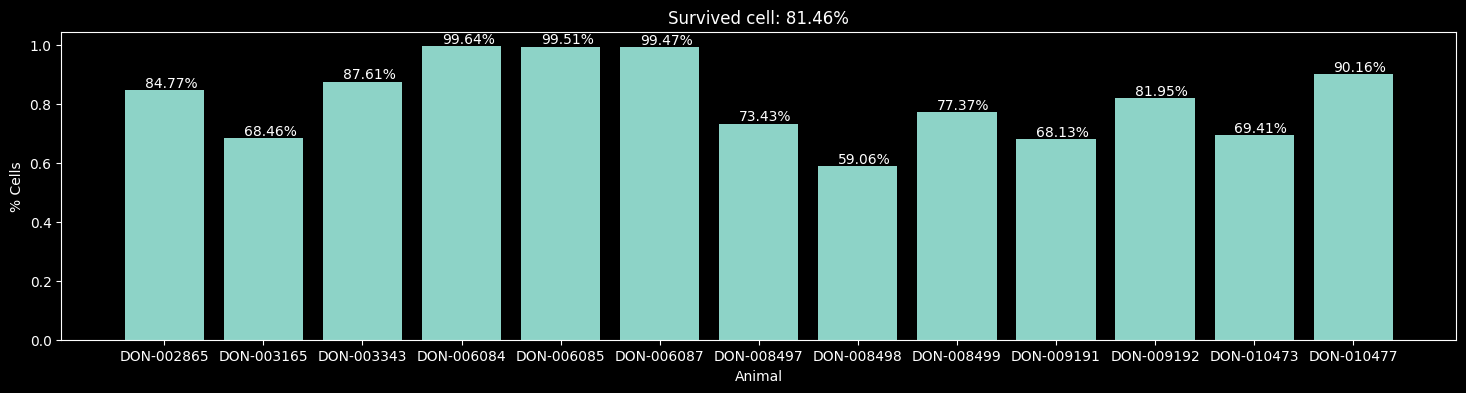

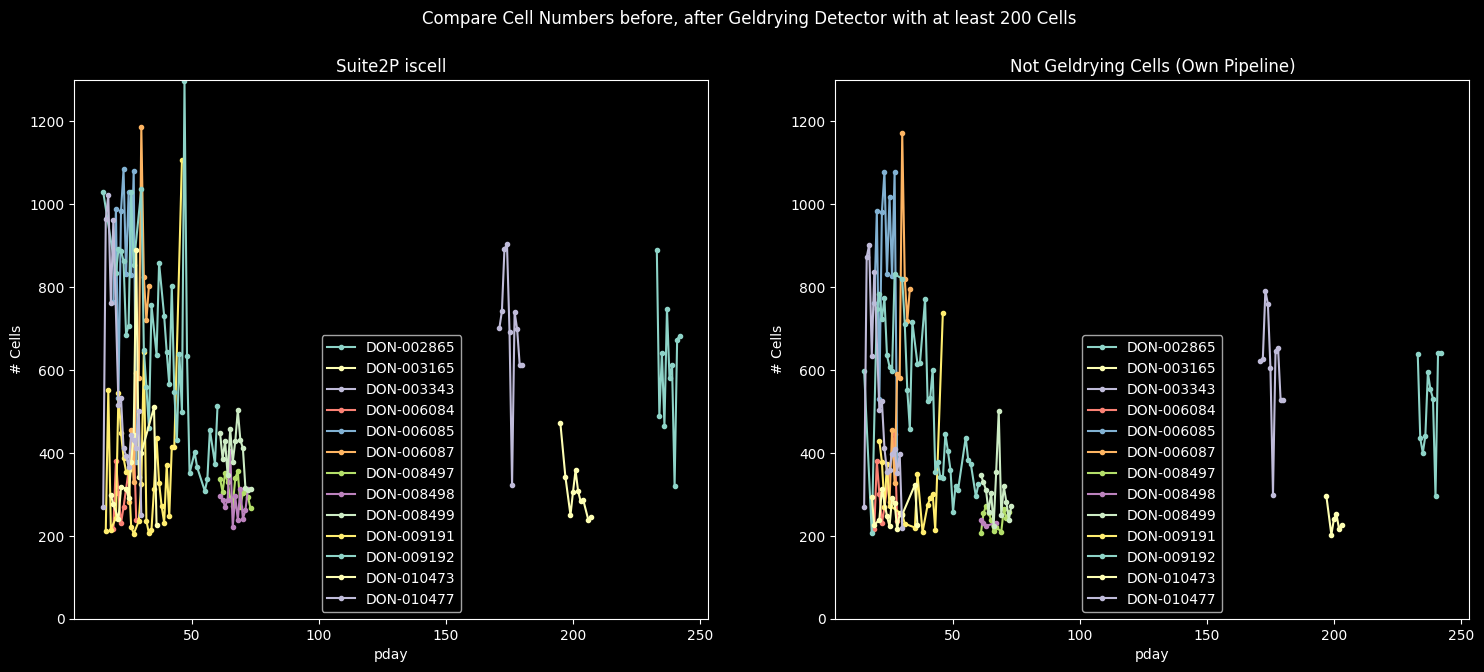

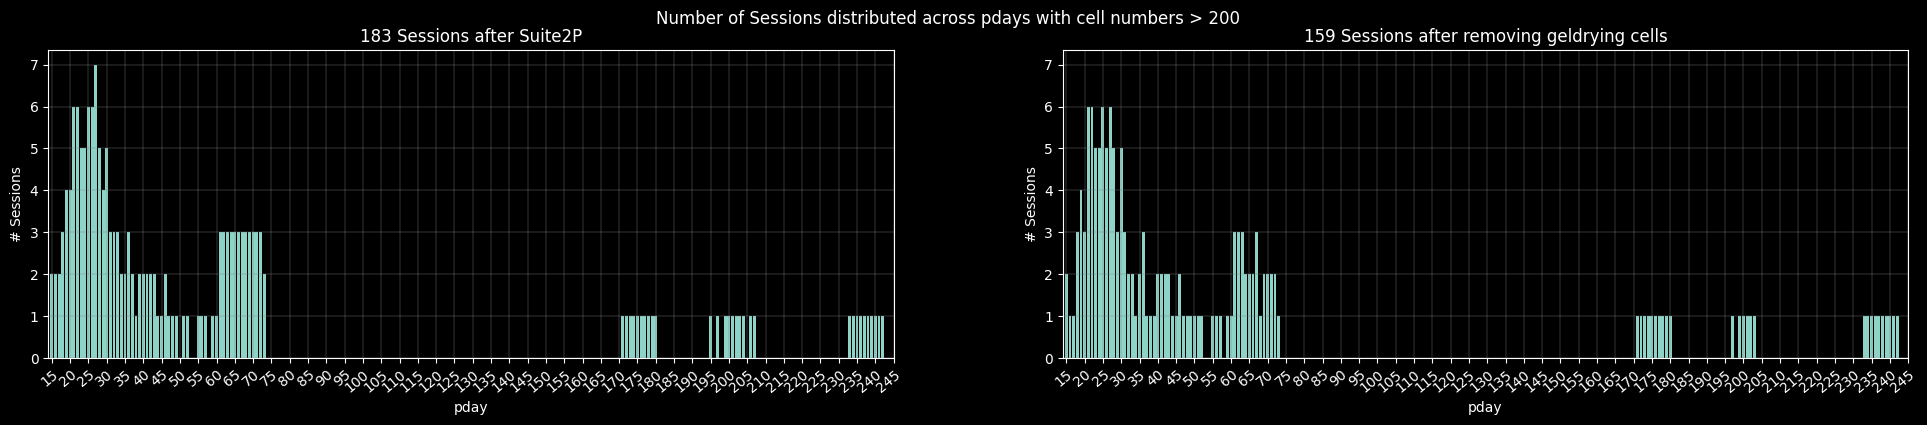

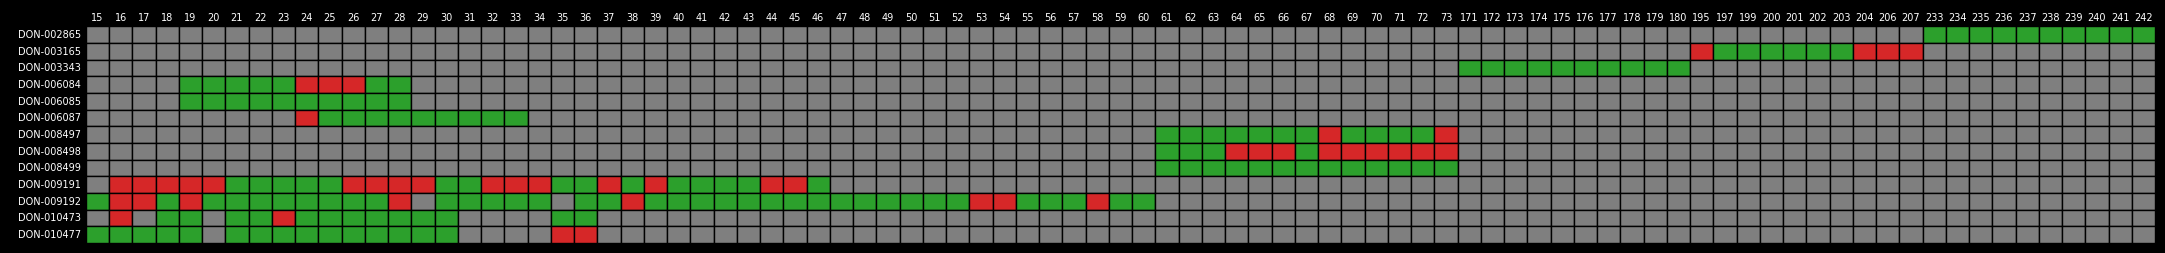

In [73]:
# Plot to show survived cell percentages
viz.show_survived_cell_percentage(pipeline_stats=pipeline_stats)
# Create table to show statistics for comparison of S2P vs Own Pipeline
# Plot number of cells comparisson S2P vs Geldrying cleaned S2P
viz.show_survived_cell_numbers(cell_numbers_dict=cell_numbers_dict, min_num_cells=200)
viz.show_usefull_sessions_comparisson(cell_numbers_dict=cell_numbers_dict, min_num_cells=200)
#show tabular visualization of usefull mice
pday_cell_count_df = viz.plot_usefull_session_pdays(cell_numbers_dict=cell_numbers_dict, min_num_cells=200)

In [ ]:
#Plotting Histograms, KDE, Mean Std, Bursts, Fluorescence, contours good bad 
needed = False
if needed:
    #Plotting histograms
    unit_ids = ["all", "merged"]
    for animal_id, animal in animals.items():
        for session_id, session in animal.sessions.items():
            for unit_id in unit_ids:
                title_unit_text = "Suite2P" if unit_id == "all" else unit_id           
                #Histogram
                plot_title = f"Corr_Hist {animal_id} {session_id} {title_unit_text}"
                png_path = os.path.join(root_dir, "figures", plot_title.replace(" ", "_")+".png")
                if not os.path.exists(png_path):
                    print(f"{animal_id} {session_id} {unit_id}")
                    corr_matrix, pval_matrix = viz.pearson_hist(animal_id, session_id, unit_id=unit_id, 
                                                                show_geldrying_cells=False, generate_corr=False,
                                                                color_classify=True)
    
    #Plotting KDE for every mouse(Kernel Density Estimation)
    unit_ids = ["all", "merged"]
    filters = list(animals.keys())
    x_axes_ranges = [[-0.1, 0.3], [-0.2, 0.5], [-0.75, 1.05]]
    for x_axes_range in x_axes_ranges:
        for unit_id in unit_ids:
                title_unit_text = "Suite2P" if unit_id == "all" else unit_id   
                for filter in filters:
                    plot_title = f"All correlation coefficient KDE {[filter]} {title_unit_text} {x_axes_range}"
                    print(plot_title)
                    png_path = os.path.join(root_dir, "figures", plot_title.replace(" ", "_")+".png")
                    if not os.path.exists(png_path):
                        viz.pearson_kde(filters=filter, x_axes_range=x_axes_range, unit_id=unit_id, remove_geldrying=True)
    
    #Plotting KDE for every year averaged by age(Kernel Density Estimation)
unit_ids = ["all", "merged"]
filters = [2021, 2022]
x_axes_ranges = [[-0.1, 0.3], [-0.2, 0.5], [-0.75, 1.05]]
for x_axes_range in x_axes_ranges:
    for unit_id in unit_ids:
            title_unit_text = "Suite2P" if unit_id == "all" else unit_id   
            for filter in filters:
                plot_title = f"All correlation coefficient KDE {[filter]} {title_unit_text} {x_axes_range}"
                print(plot_title)
                png_path = os.path.join(root_dir, "figures", plot_title.replace(" ", "_")+".png")
                if not os.path.exists(png_path):
                    viz.pearson_kde(filters=filter, x_axes_range=x_axes_range, unit_id=unit_id, remove_geldrying=True, average_by_pday=True)

    #Plotting Mean Std graph
    unit_ids = ["all", "merged"]
    filters = [2021, 2022]
    for unit_id in unit_ids:
            title_unit_text = "Suite2P" if unit_id == "all" else unit_id   
            for filter in filters:
                plot_title = f"{[filters]}{title_unit_text} Means and Standard Deviations"
                png_path = os.path.join(root_dir, "figures", plot_title.replace(" ", "_")+".png")
                if not os.path.exists(png_path):
                    viz.plot_means_stds(filters=filter, unit_id=unit_id, remove_geldrying=True)

    #Plotting Bursts
    fluorescence_types = ["DFF", "F_detrended"]
    for fluorescence_type in fluorescence_types:
        for animal_id, animal in animals.items():
            for session_id, session in animal.sessions.items():
                for unit_id in ["all", "merged"]:
                    file_name = f"{animal_id} {session_id}" if unit_id=="all" else f"{animal_id} {session_id} Unit {unit_id}"
                    plot_title = f"Bursts from {file_name} {fluorescence_type}"
                    png_path = os.path.join(root_dir, "figures", plot_title.replace(" ", "_")+".png")
                    if not os.path.exists(png_path):
                        viz.bursts(animal_id, session_id, fluorescence_type=fluorescence_type, unit_id=unit_id, remove_geldrying=True)

    # Plot dff, f_Detrended, normal and merged
    import matplotlib.image as mpimg
    file_path = r"C:\Users\mauls\OneDrive\Desktop\temp\Bursts"
    for animal_id, animal in animals.items():
        for session_id, session in animal.sessions.items():
            title = f"{animal_id} {session_id} all burst plots"
            combined_plot_title = os.path.join(file_path, title.replace(" ", "_")+".png")
            if os.path.exists(combined_plot_title):
                continue
            #f_raw       = f"raw\\Bursts_from_{animal_id}_{session_id}.png"
            dff         = f"DFF\\Bursts_from_{animal_id}_{session_id}_DFF.png"
            dff_merged  = f"DFF\\Bursts_from_{animal_id}_{session_id}_Unit_merged_DFF.png"
            F_det       = f"F_detrended\\Bursts_from_{animal_id}_{session_id}_F_detrended.png"
            F_det_m     = f"F_detrended\\Bursts_from_{animal_id}_{session_id}_Unit_merged_F_detrended.png"
            
            burst_plot_paths = [[dff, dff_merged], [F_det, F_det_m]]
            #burst_plot_paths = [f_raw, dff, F_det]
            ncol = len(burst_plot_paths)
            fig, ax = plt.subplots(2, 2, figsize=(20, 12))
            fig.tight_layout()
            plt.suptitle(f"{animal_id} {session_id}")
            for num, burst_plot_path in enumerate(burst_plot_paths):
                burst_plot_path_0 = os.path.join(file_path, burst_plot_path[0])
                burst_plot_path_1 = os.path.join(file_path, burst_plot_path[1])
                try:
                    ax[num, 0].imshow(mpimg.imread(burst_plot_path_0))
                    ax[num, 0].set_axis_off()
                    ax[num, 1].imshow(mpimg.imread(burst_plot_path_1))
                    ax[num, 1].set_axis_off()
                except:
                    print(f"No Pictures found for {animal_id} {session_id}")
            plt.savefig(combined_plot_title, dpi=300)
            #plt.show()

    # Plot before after contours and good bad fluorescence
    import matplotlib.image as mpimg
    file_path = r"C:\Users\mauls\OneDrive\Desktop\temp\figures"
    for animal_id, animal in animals.items():
        for session_id, session in animal.sessions.items():
            session_path = os.path.join(file_path, animal_id, session_id)
            title = f"{animal_id} {session_id} contour fluorescence"
            combined_plot_title = os.path.join(file_path, title.replace(" ", "_")+".png")
            if os.path.exists(combined_plot_title):
                continue
            contours    = f"Contours_{animal_id}_{session_id}_MUnit_all.png"
            #bursts    = f".....F_slide_{animal_id}_{session_id}_MUnit_Already_merged_Batch_1_of_1.png"
            contours_m    = f"Contours_{animal_id}_{session_id}_MUnit_Already_merged.png"
            good_bad    = f"F_slide_{animal_id}_{session_id}_MUnit_Already_merged_Batch_1_of_1.png"
            plot_paths = [contours, contours_m, good_bad]
            ncol = len(plot_paths)
            fig, ax = plt.subplots(1, ncol, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1, 1.8]})
            fig.tight_layout()
            plt.suptitle(f"{animal_id} {session_id}")
            for num, plot_path in enumerate(plot_paths):
                plot_path = os.path.join(session_path, plot_path)
                try:
                    ax[num].imshow(mpimg.imread(plot_path))
                    ax[num].set_axis_off()
                except:
                    print(f"No Pictures found for {animal_id} {session_id}")
            plt.savefig(combined_plot_title, dpi=300)
            #plt.show()

In [3]:
def gen_plots(animal_id, sessions):
    err_texts = []
    for session_id, session in animal.sessions.items():
        viz = Vizualizer()
        dir_exist_create(os.path.join(viz.save_dir, animal_id))
        dir_exist_create(os.path.join(viz.save_dir, animal_id, session_id))
        viz.save_dir = os.path.join(viz.save_dir, animal_id, session_id)
        title_comment = f" {animal_id}_{session_id}_MUnit merged not geldrying"
        if os.path.exists(os.path.join(viz.save_dir, f"Contours_{title_comment.replace(' ', '_')}.png")):
            continue
        err_text = f"{animal_id} {session_id} Error:"
        try:
            merged_unit = session.merge_units_get_geldrying(generate=False, regenerate=False, delete_used_subsessions=False, binary_needed=False)
            units = session.units
        except:
            err_text += " loading,"
        print(f"-----------------------------------Plotting Full Session----------------------------------------")
        try:
            unit_all = session.get_Unit_all()
            viz.unit_footprints(unit_all)
            viz.unit_contours(unit_all)
        except:
            err_text += " full session"
        print(f"-----------------------------------Plotting Contours-----------------------------------")
        # print contours of all combination of units size 2
        ##################################S2P Registration (Footprint position shift determination)##############################
        try:
            best_unit = session.get_most_good_cell_unit()
            min_num_usefull_cells = best_unit.num_not_geldrying() / 3
            units = session.get_usefull_units(min_num_usefull_cells)
            for unit_id, unit in units.items():
                if unit_id != best_unit.unit_id:
                    if unit.yx_shift == [0, 0]:
                        session.calc_unit_yx_shifts(best_unit, units)
                        break
            from itertools import permutations
            unit_ids = list(units.keys())
            combinations = list(permutations(unit_ids, 2))
            #Plotting shifted contours
            for combination in combinations:
                if combination[0] < combination[1]:
                    plt.figure(figsize=(20, 20))
                    viz.multi_unit_contours(units, combination=combination, plot_center=True, shift=True)
        except:
            err_text += " contours,"
        print(f"-----------------------------------Plotting Merged Session-----------------------------------")
        # Plot merged contours
        try:
            merged_contours = best_unit.contours
            for unit_id, unit in units.items():
                if unit_id == best_unit.unit_id:
                    continue
                merged_contours = np.concatenate([merged_contours, unit.contours])
            plt.figure(figsize=(10, 10))
            title_comment = f" {animal_id}_{session_id}_MUnit_{merged_unit.unit_id} merged"
            viz.contours(merged_contours, comment=title_comment)
            plt.savefig(os.path.join(viz.save_dir, f"Contours_{title_comment.replace(' ', '_')}.png"), dpi=300)
            # Plot deduplicated contours
            viz.unit_contours(merged_unit)
        except:
            err_text += " merge contours,"   
        try:
            # plot contours without geldrying
            plt.figure(figsize=(10, 10))
            title_comment = f" {animal_id}_{session_id}_MUnit {merged_unit.unit_id} not geldrying"
            viz.contours(np.array(merged_unit.contours)[merged_unit.cell_geldrying==False], comment=title_comment)
            plt.savefig(os.path.join(viz.save_dir, f"Contours_{title_comment.replace(' ', '_')}.png"), dpi=300)
        except:
            err_text += " merge contours not geldrying," 
        try:
            # plot contours without geldrying
            viz.unit_fluorescence_good_bad(merged_unit, batch_size="all", interactive=False, plot_duplicates=False)
        except:
            err_text += " merge fluorescence good bad"   
        if err_text != f"{animal_id} {session_id} Error:":
            err_texts.append(err_text)
        try:
            del units
        except:
            print("aaaaaaaaaaaaaaaaaaaaaaaa")
        try:
            del merged_unit
        except:
            print("bbbbbbbbbbbbbbbbbbbbb")
        try:
            del unit_all
        except:
            print("ccccccccccccccccccccccccccc")
    return err_texts

In [ ]:
#DON-002865\20201016
#DON-009191\20220302
#DON-009192\20220221
#DON-010473\20220523
all_err_texts = []
needed_animal_ids = ["DON-002865", "DON-009191", "DON-009192", "DON-010473"]
for animal_id, animal in animals.items():
    #if animal_id in needed_animal_ids:
    if animal_id not in needed_animal_ids:
        continue
    err_texts = gen_plots(animal_id, animal.sessions)
    all_err_texts.append(err_texts)

# Merging

In [ ]:
plotting = True
skip_animal = ["DON-009191"]
skip_session = ["20220225"]
bad_data = []
for animal_id, animal in animals.items():
    for session_id, session in animal.sessions.items():
        try:
            #if animal_id in skip_animal and session_id in skip_session:
            #    continue
            print(f"%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% Starting {animal_id} {session_id} %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
            print(f"---------------------------Generating Initial Suite2P Files for All----------------------------------")
            session.run_suite2p(regenerate=False, units="all")
            session.get_cabincorr_data_paths(regenerate=False, units="all")

            merged_unit = session.merge_units_get_geldrying(generate=True, regenerate=False, delete_used_subsessions=False)
            units = session.units

            viz = Vizualizer()
            dir_exist_create(os.path.join(viz.save_dir, animal_id))
            dir_exist_create(os.path.join(viz.save_dir, animal_id, session_id))
            viz.save_dir = os.path.join(viz.save_dir, animal_id, session_id)

            if plotting:
                print(f"-----------------------------------Plotting-----------------------------------------------------")
                print(f"-----------------------------------Plotting Individual Munits-----------------------------------")
                for unit_id, unit in units.items():
                    viz.unit_footprints(unit)
                    viz.unit_contours(unit)
                    viz.traces(unit.fluoresence, num_cells="all", animal_id=animal_id, session_id=session_id, unit_id=unit.unit_id)
                    #viz.save_rasters_fig(unit.c, animal_id=animal_id, session_id=session_id, unit_id=unit.unit_id)
                    # Plot Good Bad fluorescence data in Batches of size 10
                    session_figure_dir = viz.save_dir
                    batch_save_dir = os.path.join(viz.save_dir, "batch_10")
                    dir_exist_create(batch_save_dir)
                    viz.save_dir = batch_save_dir
                    viz.unit_fluorescence_good_bad(unit, batch_size="all", starting=0)
                    #viz.unit_fluorescence_good_bad(unit, batch_size=10, starting=0)
                    viz.save_dir = session_figure_dir

                print(f"-----------------------------------Plotting Full Session----------------------------------------")
                # Plot Full Session Unit 
                unit_all = session.get_Unit_all()
                viz.unit_footprints(unit_all)
                viz.unit_contours(unit_all)
                viz.traces(unit_all.fluoresence, num_cells=100, animal_id=animal_id, session_id=session_id, unit_id=unit_all.unit_id)


                print(f"-----------------------------------Plotting Contours-----------------------------------")
                # print contours of all combination of units size 2
                ##################################S2P Registration (Footprint position shift determination)##############################
                best_unit = session.get_most_good_cell_unit()
                min_num_usefull_cells = best_unit.num_not_geldrying() / 3
                units = session.get_usefull_units(min_num_usefull_cells)
                for unit_id, unit in units.items():
                    if unit_id != best_unit.unit_id:
                        if unit.yx_shift == [0, 0]:
                            session.calc_unit_yx_shifts(best_unit, units)
                            break
                from itertools import permutations
                unit_ids = list(units.keys())
                combinations = list(permutations(unit_ids, 2))
                ##Plotting original contours
                #for combination in combinations:
                #    if combination[0] < combination[1]:
                #        plt.figure(figsize=(20, 20))
                #        viz.multi_unit_contours(units, combination=combination, plot_center=True)
                #Plotting shifted contours
                for combination in combinations:
                    if combination[0] < combination[1]:
                        plt.figure(figsize=(20, 20))
                        viz.multi_unit_contours(units, combination=combination, plot_center=True, shift=True)

                print(f"-----------------------------------Plotting Merged Session-----------------------------------")
                # Plot merged contours
                merged_contours = best_unit.contours
                for unit_id, unit in units.items():
                    if unit_id == best_unit.unit_id:
                        continue
                    merged_contours = np.concatenate([merged_contours, unit.contours])
                plt.figure(figsize=(10, 10))
                title_comment = f" {animal_id}_{session_id}_MUnit_{merged_unit.unit_id} merged"
                viz.contours(merged_contours, comment=title_comment)
                plt.savefig(os.path.join(viz.save_dir, f"Contours_{title_comment.replace(' ', '_')}.png"), dpi=300)

                # Plot deduplicated contours
                viz.unit_contours(merged_unit)   

                # plot contours without geldrying
                plt.figure(figsize=(10, 10))
                title_comment = f" {animal_id}_{session_id}_MUnit {merged_unit.unit_id} not geldrying"
                viz.contours(np.array(merged_unit.contours)[merged_unit.cell_geldrying==False], comment=title_comment)
                plt.savefig(os.path.join(viz.save_dir, f"Contours_{title_comment.replace(' ', '_')}.png"), dpi=300)


                #viz.unit_fluorescence_good_bad(merged_unit, batch_size=10, interactive=False, plot_duplicates=False)
                viz.unit_fluorescence_good_bad(merged_unit, batch_size="all", interactive=False, plot_duplicates=False)
        except:
            bad_data.append([animal_id, session_id])

print(f"Something went wrong with: {bad_data}")

# Example Code for Class usage

In [ ]:
#Usage Examples
#Setting 
root_dir = "D:\\Rodrigo"
animal_id = "DON-002865"
#session = "20210211"
session = "DON-002865_20210211"
yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")

#load single Session Data of animal
animal = Animal(yaml_file_name)
animal.get_session_data(session)
animal.get_overview()

# Create Vizualizer 
viz = Vizualizer({animal_id: animal})

#plot bursts and get Fluoresence
F = viz.bursts(animal_id, session, num_cells="all")
F = viz.bursts(animal_id, session, fluoresence_type="filtered", num_cells=100)

#plot pearon coefficients and histogram and get correlation data
corr_matrix, pval_matrix = viz.pearson_hist(animal_id, session, title=f"Pearson_{animal_id}_{session}.png")

#Load all animals
animals = load_all(root_dir) # Load all animals
#animals = load_all(root_dir, ["DON-002865"]) # Load specific animals
#Get overview of all sessions of an animal
df = animals["DON-002865"].get_overview()
df

# Filter for animals
filtered_animals = filter_animals(animals, filters=["DON-002865"]) # [2021, "male"]
for id, animal in filtered_animals.items():
    print(f"{id} {animal.sex}")
print("---------------------------------")
for id, animal in animals.items():
    print(f"{id} {animal.sex}")

# Plot good bad dataset count
viz.plot_good_bad(filters=[])

In [ ]:
# Create Kernel Density Estimation for every Mouse or year
for animal_id in list(animals.keys()):
    viz.pearson_kde(filters=[animal_id]) #filters=["DON-002865"]) # [2021, "male"]

In [ ]:
# Create Kernel Density Estimation for every Year
for year in year_list:
    viz.pearson_kde(filters=[year]) #filters=["DON-002865"]) # [2021, "male"]

In [ ]:
# Plot Lines for mean and standard deviation of correlation coefficients
viz.plot_means_stds(filters=[2021])

# Testing

In [ ]:
for _, unit in units_bad.items():
    viz.unit_fluorescence_good_bad(unit, batch_size=10, starting=0, interactive=True)
for _, unit in units_good.items(): 
    viz.unit_fluorescence_good_bad(unit, batch_size="all", starting=0)

#### test if geldrying cells are detected

In [ ]:
def is_geldrying(unit, cell_id, bad_minutes = 1.5, not_bad_minutes=0.4):
    sliding_cell_F = unit.get_all_sliding_cell_stat[cell_id]
    geldrying = anz.geldrying(sliding_cell_F, bad_minutes=bad_minutes, not_bad_minutes=not_bad_minutes)
    return geldrying

def are_geldrying(unit, cell_ids, bad_minutes = 1.5, not_bad_minutes=0.4):
    for cell_id in cell_ids:
        geldrying = is_geldrying(unit, cell_id, bad_minutes=bad_minutes, not_bad_minutes=not_bad_minutes)
        print(f"{cell_id}: \t {geldrying[0]}\t{geldrying[1]}")

def print_gel_drying(unit, bad_cell_ids, good_cell_ids, bad_minutes = 1.5, not_bad_minutes=0.4):
    print(f"Unit: {unit.unit_id}")
    print("ooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo")
    print("Bad Cells:")
    #274, 461, 490 is not really geldrying
    are_geldrying(unit, bad_cell_ids, bad_minutes=bad_minutes, not_bad_minutes=not_bad_minutes)
    print("-----------------------------------------")
    print("Good Cells:")
    # 50, 628 is rather bad
    are_geldrying(unit, good_cell_ids, bad_minutes=bad_minutes, not_bad_minutes=not_bad_minutes)
    print("ooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo")


In [ ]:
bad_session = animal.sessions["20220319"]
bad_unit = Unit(bad_session.s2p_folder_paths[-1], bad_session, unit_id="-9000")
bad_unit.get_all_sliding_cell_stat = anz.get_all_sliding_cell_stat(fluoresence=bad_unit.fluoresence, mode="mean")
good_session = animal.sessions["20220306"]
good_unit = Unit(good_session.s2p_folder_paths[-1], good_session, unit_id="9999")
good_unit.get_all_sliding_cell_stat = anz.get_all_sliding_cell_stat(fluoresence=good_unit.fluoresence, mode="mean")

In [ ]:
good_unit.cell_geldrying = None
os.remove(os.path.join(good_unit.suite2p_folder_path, "plane0", "cell_drying.npy"))
good_unit.get_geldrying_cells(bad_minutes = 1.5, not_bad_minutes=0.5)

In [ ]:
bad_unit.cell_geldrying = None
os.remove(os.path.join(bad_unit.suite2p_folder_path, "plane0", "cell_drying.npy"))
bad_unit.get_geldrying_cells(bad_minutes = 1.5, not_bad_minutes=0.5)

In [ ]:
bad_cell_ids = [231, 255, 274, 434, 461, 490, 553]
good_cell_ids = [15, 16, 17, 34, 39, 40, 41, 46, 50, 65, 71, 73, 103, 626, 628]
print_gel_drying(good_unit, bad_cell_ids, good_cell_ids, bad_minutes=bad_minutes, not_bad_minutes=not_bad_minutes)
#FIXME: continue improving....


In [ ]:
viz.unit_fluorescence_good_bad(good_unit, batch_size=30)#, starting=90)

In [ ]:
bad_minutes = 1.5
not_bad_minutes=0.5
baddata_bad_cell_ids = [810, 814, 818, 917, 15, 20, 130, 144, 183, 185, 186, 200, 207, 209, 231, 232, 234, 235, 280, 283, 297, 304, 327, 342, 353, 358, 366, 372, 373, 378]
baddata_good_cell_ids = [11,18, 22, 44, 50, 60, 63, 117, 157, 156, 176, 201, 205]
print_gel_drying(bad_unit, baddata_bad_cell_ids, baddata_good_cell_ids, bad_minutes = bad_minutes, not_bad_minutes=not_bad_minutes)

In [ ]:
plt.figure(figsize=(10,10))
plt.ylim(-0.1,0.8)
plt.plot(bad_unit.fluoresence[96])

In [ ]:
viz.unit_fluorescence_good_bad(bad_unit, batch_size="all")#, starting=90)

In [ ]:
#viz.unit_fluorescence_good_bad(bad_unit, batch_size=10, starting=20*40)#, starting=90)
viz.unit_fluorescence_good_bad(bad_unit, batch_size=30)#, starting=90)

In [ ]:
from Classes import *
anz = Analyzer()
#concatenadet_Unit.cell_geldrying = None
concatenadet_Unit.get_geldrying_cells()
bad = sum(concatenadet_Unit.cell_geldrying)
good = len(concatenadet_Unit.cell_geldrying)-bad
print(f"Autodetection Cells: {good+bad}    Good: {good}   geldrying:{bad} ")
#viz.unit_fluorescence_good_bad(concatenadet_Unit, batch_size=300, starting=0, interactive=True)
viz.unit_fluorescence_good_bad(concatenadet_Unit, batch_size=20, starting=0, interactive=True)

In [ ]:
for unit_id, unit in units.items():
    print(f"resetting MUnit: {unit_id}")
    data_path = os.path.join(unit.suite2p_folder_path, "plane0")
    reset_s2p_files(data_path)

## Ineractive Plot

In [ ]:
def interactive_trace(units):
    # Create the interactive widget
    num_units = len(units)
    num_cells = 1500
    interact(plot_trace, unit_id=range(1, num_units+1), cell_number=range(num_cells))#, plot_type = ["Bursts"])
anz = Analyzer()

def plot_trace(unit_id=4, cell_number=13):#, plot_type="Bursts"):
    #unit = units_bad[unit_id] #FIXME: uncomment if finished testing
    unit = merged_unit
    cell_number = int(cell_number)
    fluoresence = unit.fluoresence[cell_number]
    fig , (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 10))
    #fig , (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 10))
    ax.plot(fluoresence, label=cell_number)
    ax.set_title(f'Unit: {unit_id} Cell {cell_number}')
    ax.set_ylabel("F_filtered")
    
    seconds = 5
    num_frames = 30*seconds
    x_pos = np.arange(0, len(fluoresence), num_frames)
    x_time = [int(frame/num_frames)*seconds for frame in range(len(fluoresence)) if frame%num_frames==0] 
    x_labels = [time if time%15==0 else "" for time in x_time]
    ax.set_ylim(bottom=-0.1, top=0.8)
    ax.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax.set_xlabel("seconds")


    #sliding mean_std for F_upphase
    """
    #F_upphase_sum = np.nansum(unit.c.F_upphase_bin, axis=0)
    F_mean_stds = anz.sliding_mean_std(unit.c.F_upphase_bin[cell_number], 30*60)
    #F_upphase_sum = butter_lowpass_filter(F_upphase_sum, cutoff=0.5, fs=30, order=2)
    #F_mean_stds = anz.sliding_mean_std(unit.c.F_upphase_bin, 30*60)
    F_means = F_mean_stds[:,0]
    ax2.set_ylabel("F_upphase + sliding mean")
    ax2.plot(F_means)
    ax2.set_ylim(bottom=-0.1, top=0.2)
    ax2.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax2.set_xlabel("seconds")
    """
    # sliding mean
    F_mean_stds = anz.sliding_mean_std(fluoresence, 30*60)
    F_means = F_mean_stds[:,0]
    ax2.set_ylabel("Sliding Mean")
    ax2.plot(F_means, label="Mean")
    ax2.set_ylim(bottom=-0.1, top=0.4)
    ax2.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax2.set_xlabel("seconds")

    #sliding mode
    F_mean_stds = anz.sliding_mode_std(fluoresence, 30*60)
    F_means = F_mean_stds[:,0]
    ax2.set_ylabel("Sliding Mode")
    ax2.plot(F_means, label="Mode")
    ax2.set_ylim(bottom=-0.1, top=0.4)
    ax2.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    ax2.legend()
    #ax2.set_xlabel("seconds")

    # sliding std
    F_mean_stds = anz.sliding_mean_std(fluoresence, 30*60)
    F_means = F_mean_stds[:,1]
    ax3.set_ylabel("Sliding Standard Deviation")
    ax3.plot(F_means)
    ax3.set_ylim(bottom=-0.1, top=0.4)
    ax3.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax2.set_xlabel("seconds")
    
    #Speed change can be used for spike detection
    """change_per_window = [0]
    old_mean = F_means[0] 
    for mean in F_means[1:]:
        change_per_window.append(mean-old_mean)
        old_mean = mean
    ax4.plot(change_per_window)
    #ax4.set_ylim(bottom=-0.1, top=0.4)
    ax4.set_ylabel("mean acceleration")
    ax4.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    ax4.set_xlabel("seconds")"""

    mean_stds = unit.get_all_sliding_cell_stat[cell_number]
    cell_geldrying, cell_geldrying_reasons = anz.geldrying(mean_stds)
    print(f"Moving Average: {cell_geldrying}")
    print(cell_geldrying_reasons)
    

In [ ]:
interactive_trace(units_bad)

In [ ]:
units[3].suite2p_folder_path

In [ ]:
viz.contours(units[2].contours)

In [ ]:
viz.contours(units[3].contours)

In [ ]:
animals["DON-009191"].sessions["20220225"].s2p_folder_paths[2]

In [ ]:
unit = Unit(animals["DON-009191"].sessions["20220225"].s2p_folder_paths[2], animals["DON-009191"].sessions["20220225"], unit_id=99)

In [ ]:
mesc_file_name = "DON-009191_20220225_002P-F_S2-S3.mesc"
mesc_path = "D:\\Steffen_Experiments\\DON-009191\\20220225\\002P-F"
h5 = h5py.File(os.path.join(mesc_path, mesc_file_name), 'r')

In [5]:
session.generate_tiff_from_mesc(units="S2", regenerate=True)
session.generate_tiff_from_mesc(units="S3", regenerate=True)

Merging Mesc to Tiff...
session loaded:  MUnit_0
processing:  MUnit_0


KeyboardInterrupt: 

In [ ]:
session.generate_tiff_from_mesc(units="S3", regenerate=True)

Merging Mesc to Tiff...
session loaded:  MUnit_1
processing:  MUnit_1


MemoryError: Unable to allocate 27.2 GiB for an array with shape (55748, 512, 512) and data type uint16

In [ ]:
session.run_suite2p(regenerate=True, units="S2")
session.run_suite2p(regenerate=True, units="S3")

In [4]:
units = session.get_units(get_geldrying=True)

D:\Steffen_Experiments\DON-009191\20220226\002P-F\tif\suite2p_S2\plane0
Suite2p: Cells: 14  Good: 11.0  Bad: 3.0


  0%|          | 0/11 [00:00<?, ?it/s]

ValueError: negative dimensions are not allowed

In [8]:
mesc_file_name = "DON-009191_20220226_002P-F_S2-S3.mesc"
mesc_path = "D:\\Steffen_Experiments\\DON-009191\\20220226\\002P-F"
h5 = h5py.File(os.path.join(mesc_path, mesc_file_name), 'r')

In [9]:
for munit_id, MUnits in h5['MSession_0'].items():
    print(munit_id)
    print(MUnits['Channel_0'])

MUnit_0
<HDF5 dataset "Channel_0": shape (55748, 512, 512), type "<u2">
MUnit_1
<HDF5 dataset "Channel_0": shape (55748, 512, 512), type "<u2">
MUnit_2
<HDF5 dataset "Channel_0": shape (102, 512, 512), type "<u2">
MUnit_3
<HDF5 dataset "Channel_0": shape (102, 512, 512), type "<u2">


In [6]:
session = animals["DON-009191"].sessions["20220226"]
session.s2p_folder_paths

['D:\\Steffen_Experiments\\DON-009191\\20220226\\002P-F\\tif\\suite2p',
 'D:\\Steffen_Experiments\\DON-009191\\20220226\\002P-F\\tif\\suite2p_S2',
 'D:\\Steffen_Experiments\\DON-009191\\20220226\\002P-F\\tif\\suite2p_S3']

In [11]:
for path in session.s2p_folder_paths:
    path = os.path.join(path, "plane0", "F.npy")
    F = np.load(path)
    print(F.shape)

(128, 55850)
(14, 102)
(143, 55748)


In [ ]:
session.run_suite2p(regenerate=True, units="S2")

In [ ]:
h5['MSession_0']['MUnit_2']['Channel_0']

In [ ]:
unit.c.F.shape

In [ ]:
unit.get_geldrying_cells()
#unit.get_all_sliding_cell_stat()

C:\Users\mauls\AppData\Local\Temp\ipykernel_33756\572866968.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  viz.contours(np.array(merged_unit.contours)[merged_unit.cell_geldrying==False], comment=title_comment)


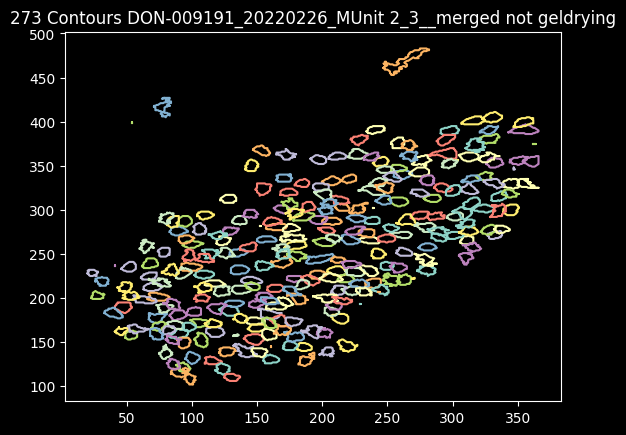

In [16]:
title_comment = f" {animal_id}_{session_id}_MUnit {merged_unit.unit_id} not geldrying"
viz.contours(np.array(merged_unit.contours)[merged_unit.cell_geldrying==False], comment=title_comment)

In [4]:
for uid, unit in units.items():
    print(unit.animal_id)
    print(unit.session_id)
    print(len(unit.contours))
    print(unit.yx_shift)

NameError: name 'units' is not defined

In [3]:
root_dir = "\\\\toucan-all.scicore.unibas.ch\\donafl00-calcium$\\Users\\Sergej\\Steffen_Experiments"  
#root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments" 
#root_dir = "D:\\Steffen_Experiments"  
#root_dir = "F:\\Steffen_Experiments"
Animal.root_dir = root_dir
an = animals = load_all(root_dir) # Load all animals

for animal_id, animal in an.items():
    for session_id, session in animal.sessions.items():
        if "S1" not in session.mesc_data_path:
            print(session.mesc_data_path)

\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220225\002P-F\DON-009191_20220225_002P-F_S2-S3.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220226\002P-F\DON-009191_20220226_002P-F_S2-S3.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220227\002P-F\DON-009191_20220227_002P-F_S2-S3.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220228\002P-F\DON-009191_20220228_002P-F_S2-S3.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220301\002P-F\DON-009191_20220301_002P-F_S2-S3.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009191\20220305\002P-F\DON-009191_20220305_002P-F_S4.mesc
\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\DON-009192\20220224\002P-F\DON-009192_2

In [ ]:
# binary to gif to mp4
data_path = r"F:\Renan"
frame_ranges = [[50, 100], [500, 1000], [5000, 6000], [0, 9001]]
image_x_size, image_y_size = 512, 512
n_frames_to_be_acquired = 167220 # sum of frames of every mesc file
loader = Binary_loader()
frames = loader.load_binary(data_path, n_frames_to_be_acquired, "data.bin", image_x_size, image_y_size)

animation_path = os.path.join(data_path, "animation")
frame_range=[0, 9001]
loader.binary_frames_to_animation(frames, frame_range=frame_range, save_dir=animation_path)
git_to_mp4(os.path.join(animation_path, f"{frame_range[0]}-{frame_range[1]}"))
# Only to plot individual frames
#viz = Vizualizer()
#viz.binary_frames(frames[:10], num_images_x=5)